In [5]:
# [환경 설정] 한글 폰트 설정 및 필수 라이브러리 로드
# macOS, Windows, Linux, Google Colab 환경에 맞춰 한글 깨짐 없이 동작하도록 자동 감지 설정합니다.

import platform
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import pandas as pd
import numpy as np

try:
    import seaborn as sns
except ImportError:
    pass

# 운영체제(OS)별 한글 폰트 자동 설정
system_name = platform.system()
if system_name == 'Darwin':          # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
    plt.rcParams['font.sans-serif'] = ['AppleGothic', 'Apple SD Gothic Neo', 'NanumGothic', 'DejaVu Sans']
elif system_name == 'Windows':       # Windows
    plt.rcParams['font.family'] = 'Malgun Gothic'
    plt.rcParams['font.sans-serif'] = ['Malgun Gothic', 'NanumGothic', 'DejaVu Sans']
else:                               # Linux / Google Colab
    try:
        nanum_fonts = [f.name for f in fm.fontManager.ttflist if 'Nanum' in f.name]
        if nanum_fonts:
            plt.rcParams['font.family'] = nanum_fonts[0]
        else:
            import subprocess
            subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], check=False, stdout=subprocess.DEVNULL)
            fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
            plt.rcParams['font.family'] = 'NanumGothic'
    except Exception:
        pass
    plt.rcParams['font.sans-serif'] = ['NanumGothic', 'DejaVu Sans']

# 마이너스 기호 깨짐 방지 및 Seaborn 폰트 동기화
plt.rcParams['axes.unicode_minus'] = False
try:
    if 'sns' in locals():
        sns.set_theme(style='whitegrid', font=plt.rcParams['font.family'])
except Exception:
    pass

print(f'✅ 환경 설정 완료! 현재 적용된 폰트: {plt.rcParams["font.family"]}')

✅ 환경 설정 완료! 현재 적용된 폰트: ['Malgun Gothic']


실습3. 센서값 추세선 그래프
- 실데이터로 한 설비 추세와 두 설비 비교 그리기

목표
- 실데이터로 한 설비 추세와 두 설비 비교 그리기

단계
- C호기 행을 골라 마커를 붙인 온도 추세 그리기
- A호기와 C호기를 겹쳐 그리고 각 선에 이름표 달기
- legend로 범례를 표시해 어느 선이 어느 설비인지 구분

예상 결과
- C호기 추세와 A·C호기 비교 그래프(범례 포함)

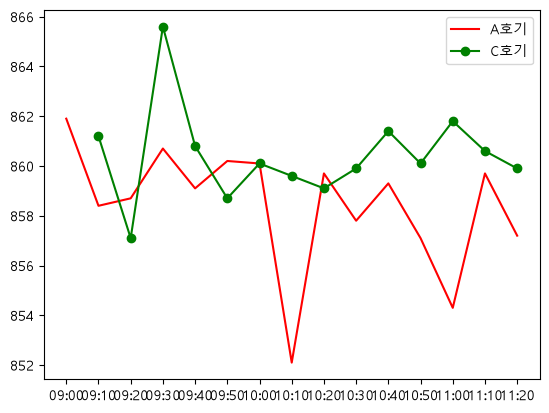

In [6]:
import matplotlib.pyplot as plt

df = pd.read_csv("../data/17_열처리.csv")

dfa = df[df["배치"] == "로트A"]
dfc = df[df["배치"] == "로트C"]

plt.plot(dfa["측정시각"], dfa["온도"], label = "A호기", color = "red")
plt.plot(dfc["측정시각"], dfc["온도"], label = "C호기", color = "green", marker = "o")
plt.legend(loc = "upper right")
plt.show()